# 03 - Regional vision-imagery RSA

Companion report: [`docs/results/rsa_results.md`](../docs/results/rsa_results.md).

Notebook 02 identified a **pilot lead** in `subj01`: Set B natural-image geometry appeared similar across vision and imagery. This notebook asks whether that lead replicates in held-out subjects 02-08 and how transfer differs across early and broader higher-visual ROIs. HOG and CLIP provide a secondary feature-model follow-up.

The analysis is intentionally staged:

1. Establish neural reliability and vision-imagery transfer across subjects and ROIs.
2. Only then interpret the geometry using low-level HOG and higher-level CLIP features.

Set A is the controlled low-level comparison. Set C remains exploratory and is excluded because it lacks one fixed visual exemplar per concept.

## 0. Update the environment once

Notebook 03 adds `scikit-image`, PyTorch, and Transformers. From a terminal in the repository, run:

```bash
conda env update -n nsdimagery -f environment.yml
```

Then restart Jupyter and explicitly select **Kernel -> Change Kernel -> Python (NSD-Imagery)**. A terminal environment and a notebook kernel are separate processes: activating conda in the terminal does not change an already-running notebook. The first cell below prints `sys.executable`; it should point inside the `nsdimagery` environment. The environment pins Python 3.12 as a conservative, reproducible common denominator across PyTorch, Transformers, and conda-forge packages. CLIP runs on CPU for only 12 images, so no GPU is required.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory.')
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
from IPython.display import display
from PIL import Image
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize

from nsdimagery import (
    balanced_split_reliability, build_event_table, correlation_rdm, cosine_rdm,
    exact_label_permutation_test, exact_sign_flip_test,
    extract_masked_betas, find_data_root, independent_group_reliability,
    load_roi, load_target_table, paths_for_subject, rdm_spearman,
    target_rdm, zscore_within_groups,
)

sns.set_theme(style='whitegrid', context='notebook')
DATA_ROOT = find_data_root(REPO_ROOT)
print('Python:', sys.version.split()[0])
print('Python executable:', sys.executable)
print('scikit-image:', skimage.__version__)
print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)

Python: 3.12.13
Python executable: /srv/conda/envs/nsdimagery/bin/python
scikit-image: 0.26.0
Repository: /home/jovyan/NHprojectNSDimagery
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd


## 1. Analysis contract

`subj01` is displayed as the pilot but excluded from confirmatory group tests. Subjects 02-08 are held out. The pre-specified neural test is positive Set B vision-imagery RDM correlation in higher visual cortex. The higher-minus-early contrast is secondary.

ROI definitions:

| Analysis ROI | Released mask | Labels |
|---|---|---|
| `nsdgeneral` | `nsdgeneral` | all positive voxels |
| `early_visual` | `prf-visualrois` | 1-6: V1-V3 dorsal/ventral |
| `higher_visual` | `streams` | 5-7: ventral, lateral, parietal |

We report all subjects; reliability is an interpretation aid, never a post-hoc exclusion rule.

In [2]:
SUBJECTS = tuple(range(1, 9))
PILOT_SUBJECT = 1
STIMULUS_SETS = ('A', 'B')
ROI_SPECS = {
    'nsdgeneral': {'mask_name': 'nsdgeneral', 'labels': None},
    'early_visual': {'mask_name': 'prf-visualrois', 'labels': tuple(range(1, 7))},
    'higher_visual': {'mask_name': 'streams', 'labels': (5, 6, 7)},
}
ROI_ORDER = list(ROI_SPECS)
MAX_VOXELS_PER_ROI = 1200
N_VISION_SPLITS = 200
BASE_SEED = 2026
RUN_CLIP = True
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

OUTPUT_DIR = REPO_ROOT / 'outputs' / '03_group_transfer_feature_rsa'
CACHE_DIR = DATA_ROOT / 'derived' / 'notebook03_beta_cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Subjects:', SUBJECTS)
print('Pilot:', PILOT_SUBJECT, '| held out:', [s for s in SUBJECTS if s != PILOT_SUBJECT])
print('Voxel cap per subject/ROI:', MAX_VOXELS_PER_ROI)
print('Beta cache:', CACHE_DIR)

Subjects: (1, 2, 3, 4, 5, 6, 7, 8)
Pilot: 1 | held out: [2, 3, 4, 5, 6, 7, 8]
Voxel cap per subject/ROI: 1200
Beta cache: /home/jovyan/NHprojectNSDimagery/data/nsd/derived/notebook03_beta_cache


The first complete run reads at most 1,200 voxels for each subject and ROI. Each extraction is cached under the data directory. Subsequent runs reuse those arrays, so statistical and plotting cells become fast. Changing the voxel cap or seed creates a distinct cache file.

In [3]:
def cache_path(subject, roi_name, seed):
    voxel_token = 'all' if MAX_VOXELS_PER_ROI is None else str(MAX_VOXELS_PER_ROI)
    return CACHE_DIR / f'subj{subject:02d}_{roi_name}_n{voxel_token}_seed{seed}.npz'

def load_or_extract_roi_betas(subject, roi_name, roi_index):
    spec = ROI_SPECS[roi_name]
    seed = BASE_SEED + subject * 100 + roi_index
    path = cache_path(subject, roi_name, seed)
    if path.is_file():
        with np.load(path) as cached:
            betas = cached['betas']
            coordinates = cached['coordinates']
        print(f'  {roi_name}: cache hit, {betas.shape[1]} voxels')
        return betas, coordinates

    mask, _ = load_roi(DATA_ROOT, subject, spec['mask_name'])
    betas, coordinates = extract_masked_betas(
        paths_for_subject(DATA_ROOT, subject)['beta'],
        mask, labels=spec['labels'], max_voxels=MAX_VOXELS_PER_ROI, seed=seed,
    )
    np.savez_compressed(path, betas=betas, coordinates=coordinates)
    print(f'  {roi_name}: extracted and cached {betas.shape[1]} voxels')
    return betas, coordinates

## 2. Build neural RDMs across all subjects

For each subject and ROI we:

1. select the 432 vision/imagery beta patterns;
2. standardize each voxel within its run;
3. average target repetitions;
4. compare vision and imagery RDMs;
5. estimate vision reliability using 200 balanced random half-splits;
6. estimate imagery reliability by comparing the two independent imagery runs.

This is the longest cell on its first run. Progress is printed by subject and ROI.

In [4]:
neural_rows = []
neural_rdms = {}

for subject in SUBJECTS:
    print(f'\nsubj{subject:02d}')
    events = build_event_table(DATA_ROOT, subject).reset_index(drop=True)
    for roi_index, roi_name in enumerate(ROI_ORDER):
        all_betas, coordinates = load_or_extract_roi_betas(subject, roi_name, roi_index)
        trial_patterns = all_betas[events['beta_index'].to_numpy()]
        normalized = zscore_within_groups(trial_patterns, events['run_name'].to_numpy())

        for set_index, stimulus_set in enumerate(STIMULUS_SETS):
            task_rdms = {}
            for task in ('vision', 'imagery'):
                frame = events[
                    events['stimulus_set'].eq(stimulus_set) & events['task'].eq(task)
                ]
                positions = frame.index.to_numpy()
                rdm, target_order = target_rdm(
                    normalized[positions], frame['target_number'].to_numpy()
                )
                assert np.array_equal(target_order, np.arange(1, 7))
                task_rdms[task] = rdm
                neural_rdms[(subject, roi_name, stimulus_set, task)] = rdm

            transfer_test = exact_label_permutation_test(
                task_rdms['vision'], task_rdms['imagery']
            )
            vision_frame = events[
                events['stimulus_set'].eq(stimulus_set) & events['task'].eq('vision')
            ]
            vision_positions = vision_frame.index.to_numpy()
            split_rhos = balanced_split_reliability(
                normalized[vision_positions],
                vision_frame['target_number'].to_numpy(),
                n_splits=N_VISION_SPLITS,
                seed=BASE_SEED + subject * 1000 + roi_index * 10 + set_index,
            )
            imagery_frame = events[
                events['stimulus_set'].eq(stimulus_set) & events['task'].eq('imagery')
            ]
            imagery_positions = imagery_frame.index.to_numpy()
            imagery_reliability = independent_group_reliability(
                normalized[imagery_positions],
                imagery_frame['target_number'].to_numpy(),
                imagery_frame['run_name'].to_numpy(),
            )
            neural_rows.append({
                'subject': subject,
                'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                'roi': roi_name,
                'stimulus_set': stimulus_set,
                'n_voxels': len(coordinates),
                'vision_split_rho_median': float(np.median(split_rhos)),
                'vision_split_rho_q25': float(np.quantile(split_rhos, .25)),
                'vision_split_rho_q75': float(np.quantile(split_rhos, .75)),
                'imagery_run_rho': imagery_reliability,
                'vision_imagery_rho': transfer_test['observed'],
                'transfer_p_greater': transfer_test['p_greater'],
                'transfer_p_two_sided': transfer_test['p_two_sided'],
            })

neural_metrics = pd.DataFrame(neural_rows)
print('\nMetric rows:', len(neural_metrics))
display(neural_metrics.head(12))
assert len(neural_metrics) == len(SUBJECTS) * len(ROI_SPECS) * len(STIMULUS_SETS)


subj01
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj02
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj03
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj04
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj05
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj06
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj07
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj08
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

Metric 

,subject,phase,roi,stimulus_set,n_voxels,vision_split_rho_median,vision_split_rho_q25,vision_split_rho_q75,imagery_run_rho,vision_imagery_rho,transfer_p_greater,transfer_p_two_sided
0,1,pilot,nsdgeneral,A,1200,0.067857,-0.065179,0.239286,0.153571,0.214286,0.280556,0.545833
1,1,pilot,nsdgeneral,B,1200,0.175000,0.000000,0.339286,-0.303571,0.646429,0.018056,0.033333
2,1,pilot,early_visual,A,1200,0.407143,0.291071,0.533036,0.171429,-0.153571,0.681944,0.665278
3,1,pilot,early_visual,B,1200,-0.010714,-0.187500,0.171429,-0.410714,0.214286,0.255556,0.519444
4,1,pilot,higher_visual,A,1200,0.041071,-0.154464,0.194643,-0.010714,0.367857,0.130556,0.247222
5,1,pilot,higher_visual,B,1200,0.126786,-0.061607,0.337500,-0.307143,0.439286,0.079167,0.173611
6,2,heldout,nsdgeneral,A,1200,0.367857,0.250000,0.514286,0.292857,0.371429,0.119444,0.243056
7,2,heldout,nsdgeneral,B,1200,0.150000,0.027679,0.275893,0.114286,0.846429,0.002778,0.002778
8,2,heldout,early_visual,A,1200,0.541071,0.458036,0.640179,0.060714,0.117857,0.348611,0.730556
9,2,heldout,early_visual,B,1200,0.267857,0.131250,0.408929,-0.303571,0.614286,0.026389,0.050000


## 3. Held-out neural-transfer test

The exact six-label permutation tests in the previous table describe each subject. Generalization is assessed here with exact sign flips across subjects 02-08. With seven held-out subjects there are only $2^7=128$ possible sign patterns, so the attainable p-values are discrete.

In [5]:
heldout_neural = neural_metrics[neural_metrics['phase'].eq('heldout')].copy()
group_rows = []
for (stimulus_set, roi_name), frame in heldout_neural.groupby(['stimulus_set', 'roi']):
    values = frame['vision_imagery_rho'].to_numpy()
    test = exact_sign_flip_test(values)
    group_rows.append({
        'stimulus_set': stimulus_set,
        'roi': roi_name,
        'n_subjects': len(values),
        'mean_rho': values.mean(),
        'median_rho': np.median(values),
        'p_greater': test['p_greater'],
        'p_two_sided': test['p_two_sided'],
    })
neural_group_summary = pd.DataFrame(group_rows).sort_values(['stimulus_set', 'roi'])
display(neural_group_summary)

set_b_wide = (
    heldout_neural[heldout_neural['stimulus_set'].eq('B')]
    .pivot(index='subject', columns='roi', values='vision_imagery_rho')
)
higher_minus_early = (set_b_wide['higher_visual'] - set_b_wide['early_visual']).to_numpy()
primary_values = set_b_wide['higher_visual'].to_numpy()
primary_test = exact_sign_flip_test(primary_values)
roi_contrast_test = exact_sign_flip_test(higher_minus_early)
confirmatory_tests = pd.DataFrame([
    {
        'test': 'Set B higher-visual transfer > 0 (primary)',
        'mean_effect': primary_values.mean(),
        'p_greater': primary_test['p_greater'],
        'p_two_sided': primary_test['p_two_sided'],
    },
    {
        'test': 'Set B higher minus early transfer > 0 (secondary)',
        'mean_effect': higher_minus_early.mean(),
        'p_greater': roi_contrast_test['p_greater'],
        'p_two_sided': roi_contrast_test['p_two_sided'],
    },
])
display(confirmatory_tests)

,stimulus_set,roi,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
0,A,early_visual,7,0.415306,0.342857,0.007812,0.015625
1,A,higher_visual,7,0.269388,0.250000,0.093750,0.187500
2,A,nsdgeneral,7,0.339286,0.328571,0.015625,0.031250
3,B,early_visual,7,0.134694,-0.067857,0.234375,0.468750
4,B,higher_visual,7,0.365306,0.314286,0.007812,0.015625
5,B,nsdgeneral,7,0.364286,0.360714,0.031250,0.062500


,test,mean_effect,p_greater,p_two_sided
0,Set B higher-visual transfer > 0 (primary),0.365306,0.007812,0.015625
1,Set B higher minus early transfer > 0 (secondary),0.230612,0.164062,0.328125


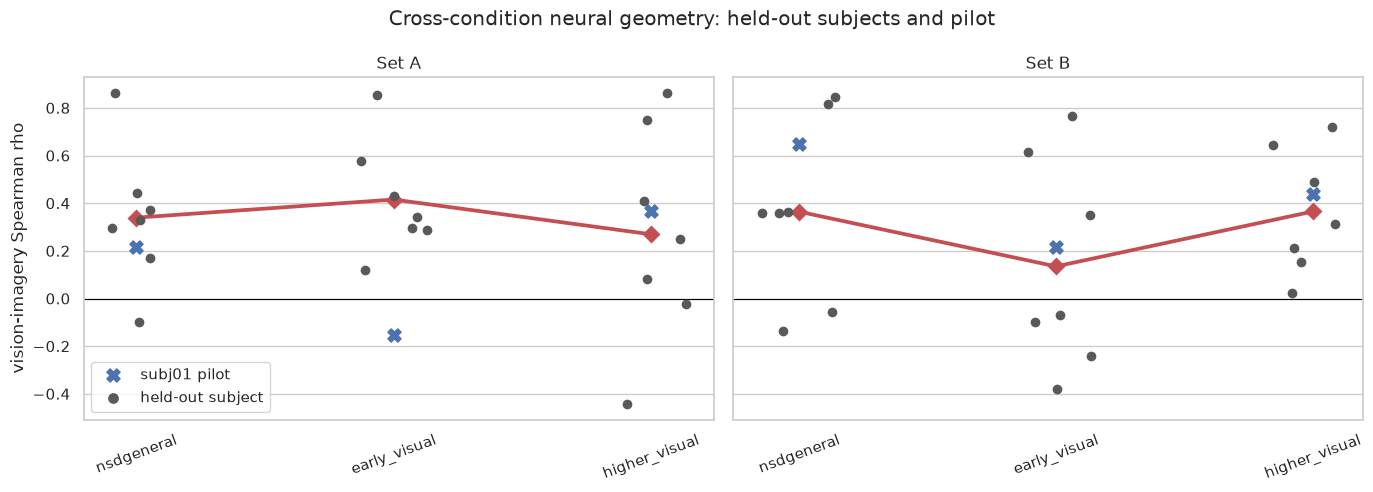

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, stimulus_set in zip(axes, STIMULUS_SETS):
    heldout = heldout_neural[heldout_neural['stimulus_set'].eq(stimulus_set)]
    pilot = neural_metrics[
        neural_metrics['stimulus_set'].eq(stimulus_set)
        & neural_metrics['phase'].eq('pilot')
    ]
    sns.stripplot(
        data=heldout, x='roi', y='vision_imagery_rho', order=ROI_ORDER,
        color='0.35', jitter=.16, size=7, ax=ax,
    )
    sns.pointplot(
        data=heldout, x='roi', y='vision_imagery_rho', order=ROI_ORDER,
        color='#c44e52', errorbar=None, markers='D', linestyles='-', ax=ax,
    )
    for x, roi_name in enumerate(ROI_ORDER):
        value = pilot.loc[pilot['roi'].eq(roi_name), 'vision_imagery_rho'].iloc[0]
        ax.scatter(x, value, marker='X', s=90, color='#4c72b0', zorder=5)
    ax.axhline(0, color='black', linewidth=.8)
    ax.set(title=f'Set {stimulus_set}', xlabel='', ylabel='vision-imagery Spearman rho')
    ax.tick_params(axis='x', rotation=20)
axes[0].scatter([], [], marker='X', s=90, color='#4c72b0', label='subj01 pilot')
axes[0].scatter([], [], marker='o', s=45, color='0.35', label='held-out subject')
axes[0].legend(loc='lower left')
fig.suptitle('Cross-condition neural geometry: held-out subjects and pilot')
plt.tight_layout()

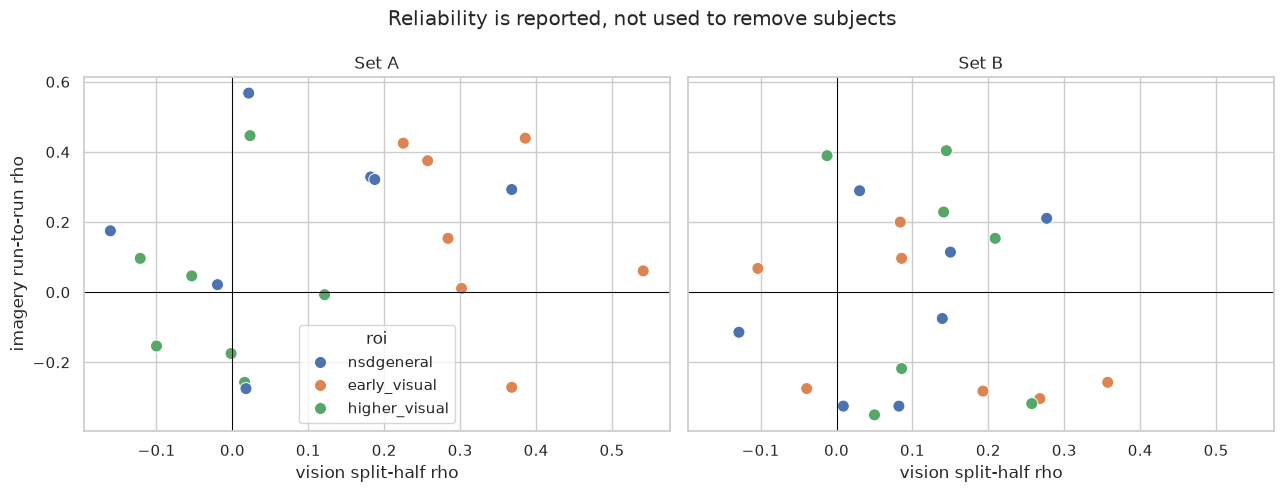

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, stimulus_set in zip(axes, STIMULUS_SETS):
    frame = heldout_neural[heldout_neural['stimulus_set'].eq(stimulus_set)]
    sns.scatterplot(
        data=frame, x='vision_split_rho_median', y='imagery_run_rho',
        hue='roi', hue_order=ROI_ORDER, s=75, ax=ax,
    )
    ax.axhline(0, color='black', linewidth=.7)
    ax.axvline(0, color='black', linewidth=.7)
    ax.set(title=f'Set {stimulus_set}', xlabel='vision split-half rho', ylabel='imagery run-to-run rho')
axes[1].get_legend().remove()
fig.suptitle('Reliability is reported, not used to remove subjects')
plt.tight_layout()

### Neural decision point

The primary evidence is the held-out Set B higher-visual distribution and its sign-flip test, not the pilot marker. Positive transfer with reasonable run-to-run imagery reliability supports feature interpretation. A weak or heterogeneous result is still informative: it means the apparent `subj01` transfer is not a stable population effect in this small dataset. Do not tune ROIs or remove subjects in response to this table.

## 4. Build HOG and CLIP feature RDMs

HOG encodes local edge orientation and spatial layout. CLIP image embeddings provide a higher-level visual-semantic representation. Both are computed from the same 12 fixed target images in sets A and B. Feature RDMs use cosine distance, the native comparison for normalized CLIP embeddings; RSA compares RDM ranks, not raw distance scales.

In [8]:
targets = (
    load_target_table(DATA_ROOT)
    .query('stimulus_set in @STIMULUS_SETS')
    .sort_values(['stimulus_set', 'target_number'])
    .reset_index(drop=True)
)
assert targets['image_path'].notna().all()
assert targets.groupby('stimulus_set').size().eq(6).all()
display(targets[['stimulus_set', 'target_number', 'target_code', 'target_name']])

def extract_hog(paths):
    vectors = []
    for path in paths:
        with Image.open(path) as image:
            rgb = np.asarray(image.convert('RGB'), dtype=np.float32) / 255
        gray = rgb2gray(resize(rgb, (224, 224), anti_aliasing=True))
        vectors.append(hog(
            gray, orientations=9, pixels_per_cell=(16, 16),
            cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True,
        ))
    return np.stack(vectors)

feature_vectors = {}
for stimulus_set, frame in targets.groupby('stimulus_set', sort=True):
    feature_vectors[(stimulus_set, 'HOG')] = extract_hog(frame['image_path'].tolist())
    print(f'Set {stimulus_set} HOG:', feature_vectors[(stimulus_set, 'HOG')].shape)

,stimulus_set,target_number,target_code,target_name
0,A,1,H,bar_000.0deg_450L_43W.png
1,A,2,R,bar_045.0deg_450L_43W.png
2,A,3,V,bar_090.0deg_450L_43W.png
3,A,4,L,bar_135.0deg_450L_43W.png
4,A,5,P,crs_000.0deg_450L_43W.png
5,A,6,E,crs_045.0deg_450L_43W.png
6,B,1,W,shared0385_nsd28752.png
7,B,2,K,shared0413_nsd30857.png
8,B,3,B,shared0741_nsd53882.png
9,B,4,C,shared0842_nsd61178.png


Set A HOG: (6, 6084)
Set B HOG: (6, 6084)


In [9]:
clip_error = None
if RUN_CLIP:
    try:
        import torch
        import transformers
        from transformers import AutoProcessor, CLIPVisionModelWithProjection

        print('PyTorch:', torch.__version__)
        print('Transformers:', transformers.__version__)
        print('Loading:', CLIP_MODEL_NAME)
        processor = AutoProcessor.from_pretrained(CLIP_MODEL_NAME)
        model = CLIPVisionModelWithProjection.from_pretrained(CLIP_MODEL_NAME).eval()
        clip_vectors = {}
        for stimulus_set, frame in targets.groupby('stimulus_set', sort=True):
            images = []
            for path in frame['image_path']:
                with Image.open(path) as image:
                    images.append(image.convert('RGB').copy())
            inputs = processor(images=images, return_tensors='pt')
            with torch.inference_mode():
                vectors = model(pixel_values=inputs['pixel_values']).image_embeds
                vectors = vectors / vectors.norm(dim=1, keepdim=True)
            clip_vectors[(stimulus_set, 'CLIP')] = vectors.cpu().numpy()
            print(f'Set {stimulus_set} CLIP:', vectors.shape)
        feature_vectors.update(clip_vectors)
        del model
    except Exception as error:
        clip_error = error
        feature_vectors = {key: value for key, value in feature_vectors.items() if key[1] != 'CLIP'}
        print('CLIP unavailable; neural transfer and HOG RSA can still finish.')
        print(type(error).__name__ + ':', error)
        if isinstance(error, ModuleNotFoundError):
            print('This kernel is missing a CLIP dependency.')
            print('Current Python:', sys.executable)
            print('Select the Python (NSD-Imagery) kernel, then restart and run all cells.')
else:
    print('RUN_CLIP=False; skipping CLIP by configuration.')

/srv/conda/envs/nsdimagery/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.12.1
Transformers: 5.14.1
Loading: openai/clip-vit-base-patch32


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 22265.12it/s]
[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp

Set A CLIP: torch.Size([6, 512])
Set B CLIP: torch.Size([6, 512])


,stimulus_set,HOG_CLIP_rho
0,A,-0.396417
1,B,0.353571


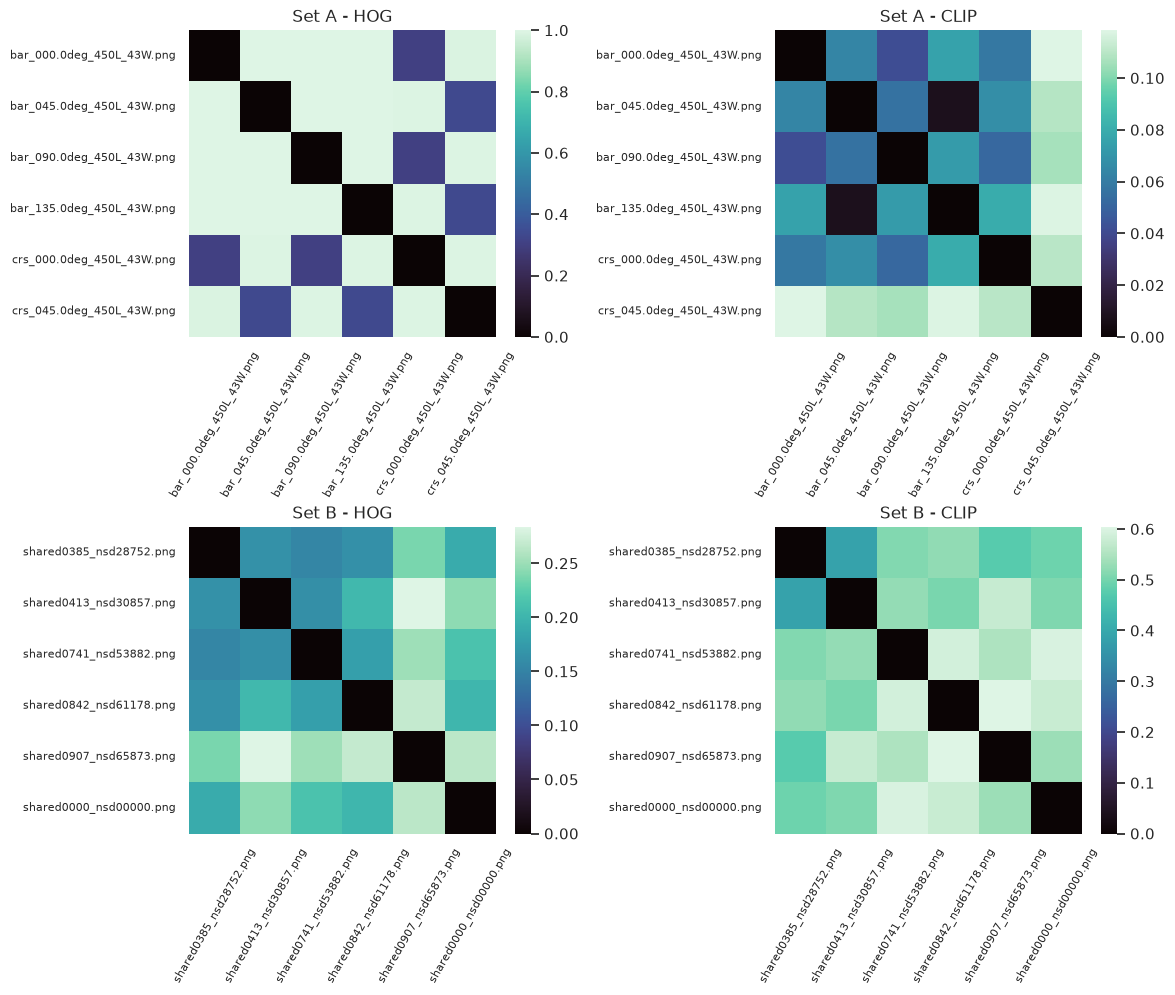

In [10]:
feature_rdms = {key: cosine_rdm(vectors) for key, vectors in feature_vectors.items()}
feature_models = [model for model in ('HOG', 'CLIP') if ('A', model) in feature_rdms]
fig, axes = plt.subplots(2, len(feature_models), figsize=(6 * len(feature_models), 10), squeeze=False)
for row, stimulus_set in enumerate(STIMULUS_SETS):
    labels = targets.loc[targets['stimulus_set'].eq(stimulus_set), 'target_name'].tolist()
    for column, feature_model in enumerate(feature_models):
        ax = axes[row, column]
        sns.heatmap(
            feature_rdms[(stimulus_set, feature_model)], square=True, cmap='mako',
            xticklabels=labels, yticklabels=labels, ax=ax,
        )
        ax.set_title(f'Set {stimulus_set} - {feature_model}')
        ax.tick_params(axis='x', rotation=60, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()

if 'CLIP' in feature_models:
    model_correlations = pd.DataFrame([
        {
            'stimulus_set': stimulus_set,
            'HOG_CLIP_rho': rdm_spearman(
                feature_rdms[(stimulus_set, 'HOG')],
                feature_rdms[(stimulus_set, 'CLIP')],
            ),
        }
        for stimulus_set in STIMULUS_SETS
    ])
    display(model_correlations)

With only six targets, each RDM contains 15 pairwise distances. HOG and CLIP may themselves be correlated. Their RDM correlation above is therefore part of the interpretation, and feature results should be presented as converging or contrasting probes rather than perfectly isolated processing levels.

## 5. Feature RSA across subjects

For every subject, ROI, set, task, and available feature model, we correlate the neural and feature RDM upper triangles. Exact target-label permutations accompany each RSA coefficient. Group inference again uses only subjects 02-08.

In [11]:
rsa_rows = []
for (subject, roi_name, stimulus_set, task), neural_rdm in neural_rdms.items():
    for feature_model in feature_models:
        test = exact_label_permutation_test(
            neural_rdm, feature_rdms[(stimulus_set, feature_model)]
        )
        rsa_rows.append({
            'subject': subject,
            'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
            'roi': roi_name,
            'stimulus_set': stimulus_set,
            'task': task,
            'feature_model': feature_model,
            'rsa_rho': test['observed'],
            'p_greater': test['p_greater'],
            'p_two_sided': test['p_two_sided'],
        })
rsa = pd.DataFrame(rsa_rows)
heldout_rsa = rsa[rsa['phase'].eq('heldout')].copy()
print('RSA rows:', len(rsa))
display(rsa.head(12))

RSA rows: 192


,subject,phase,roi,stimulus_set,task,feature_model,rsa_rho,p_greater,p_two_sided
0,1,pilot,nsdgeneral,A,vision,HOG,0.430498,0.033333,0.063889
1,1,pilot,nsdgeneral,A,vision,CLIP,0.135714,0.205556,0.420833
2,1,pilot,nsdgeneral,A,imagery,HOG,-0.401798,0.918056,0.105556
3,1,pilot,nsdgeneral,A,imagery,CLIP,0.271429,0.056944,0.144444
4,1,pilot,nsdgeneral,B,vision,HOG,0.053571,0.331944,0.736111
5,1,pilot,nsdgeneral,B,vision,CLIP,-0.139286,0.745833,0.529167
6,1,pilot,nsdgeneral,B,imagery,HOG,-0.096429,0.765278,0.491667
7,1,pilot,nsdgeneral,B,imagery,CLIP,-0.285714,0.962500,0.090278
8,1,pilot,early_visual,A,vision,HOG,0.457404,0.008333,0.047222
9,1,pilot,early_visual,A,vision,CLIP,0.046429,0.440278,0.820833


In [12]:
rsa_group_rows = []
for keys, frame in heldout_rsa.groupby(['stimulus_set', 'task', 'roi', 'feature_model']):
    values = frame['rsa_rho'].to_numpy()
    test = exact_sign_flip_test(values)
    rsa_group_rows.append({
        **dict(zip(['stimulus_set', 'task', 'roi', 'feature_model'], keys)),
        'n_subjects': len(values),
        'mean_rho': values.mean(),
        'median_rho': np.median(values),
        'p_greater': test['p_greater'],
        'p_two_sided': test['p_two_sided'],
    })
rsa_group_summary = pd.DataFrame(rsa_group_rows)
display(rsa_group_summary.query("stimulus_set == 'B'").sort_values(['task', 'roi', 'feature_model']))

,stimulus_set,task,roi,feature_model,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
12,B,imagery,early_visual,CLIP,7,-0.189796,-0.135714,1.000000,0.015625
13,B,imagery,early_visual,HOG,7,-0.058163,-0.096429,0.898438,0.234375
14,B,imagery,higher_visual,CLIP,7,-0.020408,-0.046429,0.640625,0.750000
15,B,imagery,higher_visual,HOG,7,0.111735,0.150000,0.093750,0.187500
16,B,imagery,nsdgeneral,CLIP,7,-0.037245,0.057143,0.640625,0.734375
17,B,imagery,nsdgeneral,HOG,7,0.050510,0.050000,0.281250,0.562500
18,B,vision,early_visual,CLIP,7,-0.258673,-0.342857,0.992188,0.031250
19,B,vision,early_visual,HOG,7,0.107653,0.032143,0.054688,0.109375
20,B,vision,higher_visual,CLIP,7,-0.105102,-0.075000,0.984375,0.046875
21,B,vision,higher_visual,HOG,7,0.025510,-0.010714,0.320312,0.640625


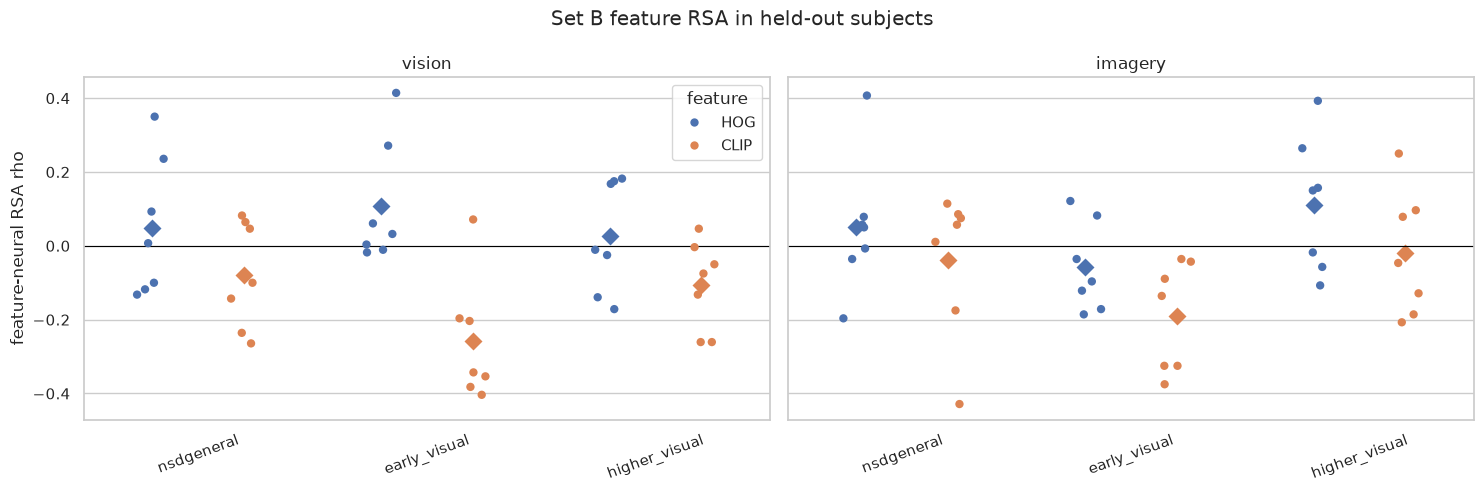

In [13]:
set_b_heldout = heldout_rsa[heldout_rsa['stimulus_set'].eq('B')]
dodge_features = len(feature_models) > 1
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, task in zip(axes, ('vision', 'imagery')):
    frame = set_b_heldout[set_b_heldout['task'].eq(task)]
    sns.stripplot(
        data=frame, x='roi', y='rsa_rho', hue='feature_model', order=ROI_ORDER,
        hue_order=feature_models, dodge=dodge_features, jitter=.14, size=6, ax=ax,
    )
    sns.pointplot(
        data=frame, x='roi', y='rsa_rho', hue='feature_model', order=ROI_ORDER,
        hue_order=feature_models, dodge=.4 if dodge_features else False,
        errorbar=None, markers='D',
        linestyles='none', ax=ax, legend=False,
    )
    ax.axhline(0, color='black', linewidth=.8)
    ax.set(title=task, xlabel='', ylabel='feature-neural RSA rho')
    ax.tick_params(axis='x', rotation=20)
right_legend = axes[1].get_legend()
if right_legend is not None:
    right_legend.remove()
axes[0].legend(title='feature')
fig.suptitle('Set B feature RSA in held-out subjects')
plt.tight_layout()

## 6. Planned feature contrasts

The first contrast asks whether CLIP explains Set B imagery geometry better than HOG in higher visual cortex. The second returns to the original transfer/drop formulation: is the vision-to-imagery loss for early-visual HOG larger than the loss for higher-visual CLIP? These are small-sample explanatory tests, secondary to the held-out neural-transfer result.

In [14]:
feature_contrasts = []
if 'CLIP' in feature_models:
    imagery_higher = (
        heldout_rsa.query("stimulus_set == 'B' and task == 'imagery' and roi == 'higher_visual'")
        .pivot(index='subject', columns='feature_model', values='rsa_rho')
    )
    semantic_advantage = (imagery_higher['CLIP'] - imagery_higher['HOG']).to_numpy()
    semantic_test = exact_sign_flip_test(semantic_advantage)
    feature_contrasts.append({
        'contrast': 'Set B imagery: higher-visual CLIP minus HOG',
        'mean_effect': semantic_advantage.mean(),
        'p_greater': semantic_test['p_greater'],
        'p_two_sided': semantic_test['p_two_sided'],
    })

    set_b_wide_rsa = (
        heldout_rsa[heldout_rsa['stimulus_set'].eq('B')]
        .pivot(index=['subject', 'roi', 'feature_model'], columns='task', values='rsa_rho')
        .assign(drop=lambda frame: frame['vision'] - frame['imagery'])
    )
    early_hog_drop = set_b_wide_rsa.xs(('early_visual', 'HOG'), level=('roi', 'feature_model'))['drop']
    higher_clip_drop = set_b_wide_rsa.xs(('higher_visual', 'CLIP'), level=('roi', 'feature_model'))['drop']
    drop_contrast = (early_hog_drop - higher_clip_drop).to_numpy()
    drop_test = exact_sign_flip_test(drop_contrast)
    feature_contrasts.append({
        'contrast': 'Set B drop: early HOG minus higher CLIP',
        'mean_effect': drop_contrast.mean(),
        'p_greater': drop_test['p_greater'],
        'p_two_sided': drop_test['p_two_sided'],
    })
else:
    print('CLIP was unavailable, so CLIP-HOG contrasts are not computed.')

feature_contrasts = pd.DataFrame(feature_contrasts)
display(feature_contrasts)

,contrast,mean_effect,p_greater,p_two_sided
0,Set B imagery: higher-visual CLIP minus HOG,-0.132143,0.992188,0.031250
1,Set B drop: early HOG minus higher CLIP,0.250510,0.039062,0.078125


## 7. Save compact results

The beta cache stays under `data/nsd/derived` and should not be committed. The files below are compact tables and RDMs suitable for version control and later figures.

In [15]:
neural_metrics.to_csv(OUTPUT_DIR / 'neural_transfer_subject_level.csv', index=False)
neural_group_summary.to_csv(OUTPUT_DIR / 'neural_transfer_group_summary.csv', index=False)
confirmatory_tests.to_csv(OUTPUT_DIR / 'confirmatory_neural_tests.csv', index=False)
rsa.to_csv(OUTPUT_DIR / 'feature_rsa_subject_level.csv', index=False)
rsa_group_summary.to_csv(OUTPUT_DIR / 'feature_rsa_group_summary.csv', index=False)
feature_contrasts.to_csv(OUTPUT_DIR / 'feature_contrasts.csv', index=False)
np.savez_compressed(
    OUTPUT_DIR / 'neural_rdms_all_subjects.npz',
    **{
        f'subj{subject:02d}__{roi}__set{stimulus_set}__{task}': rdm
        for (subject, roi, stimulus_set, task), rdm in neural_rdms.items()
    },
)
np.savez_compressed(
    OUTPUT_DIR / 'feature_rdms.npz',
    **{f'set{stimulus_set}__{model}': rdm for (stimulus_set, model), rdm in feature_rdms.items()},
)
print('Saved compact results to:', OUTPUT_DIR)

Saved compact results to: /home/jovyan/NHprojectNSDimagery/outputs/03_group_transfer_feature_rsa


## 8. Interpretation guide

Read the results in this order:

1. **Reliability:** Are held-out Set B RDMs reproducible, particularly imagery run-to-run?
2. **Neural transfer:** Is Set B higher-visual vision-imagery correlation consistently positive in subjects 02-08?
3. **Anatomy:** Is transfer larger in higher than early visual cortex?
4. **Feature explanation:** Does CLIP outperform HOG for Set B imagery in higher visual cortex?
5. **Transfer/drop:** Is low-level early-visual alignment lost more strongly than higher-level CLIP alignment?

A positive sequence supports the refined claim that natural-image geometry transfers from perception to imagery and is relatively semantic in higher visual cortex. Mixed or null held-out results do not justify tuning the analysis around `subj01`; the defensible conclusion becomes that current NSD-Imagery sampling is insufficient for stable population-level representational geometry, motivating more repeated imagery data.

Either conclusion should include individual-subject points, exact tests, and the explicit limitation of six targets and seven held-out participants.

## 9. Regional group 6 x 6 RDMs and complete cortex contrasts

The analyses above test selected transfer and feature hypotheses. This appended section makes the regional representational geometry itself visible and completes the cortex comparison without changing the original cells.

For each set and ROI, the displayed lower triangle is the held-out mean vision RDM and the upper triangle is the held-out mean imagery RDM (subjects 02-08). We then quantify (1) how similar the RDM geometry is across ROI pairs, (2) whether vision-imagery transfer differs between every ROI pair, and (3) whether feature RSA differs between every ROI pair. All formal contrasts are paired within subject and use exact sign flips. Set C remains in Notebook 02 because Notebook 03's fixed-image feature models are defined only for sets A and B.

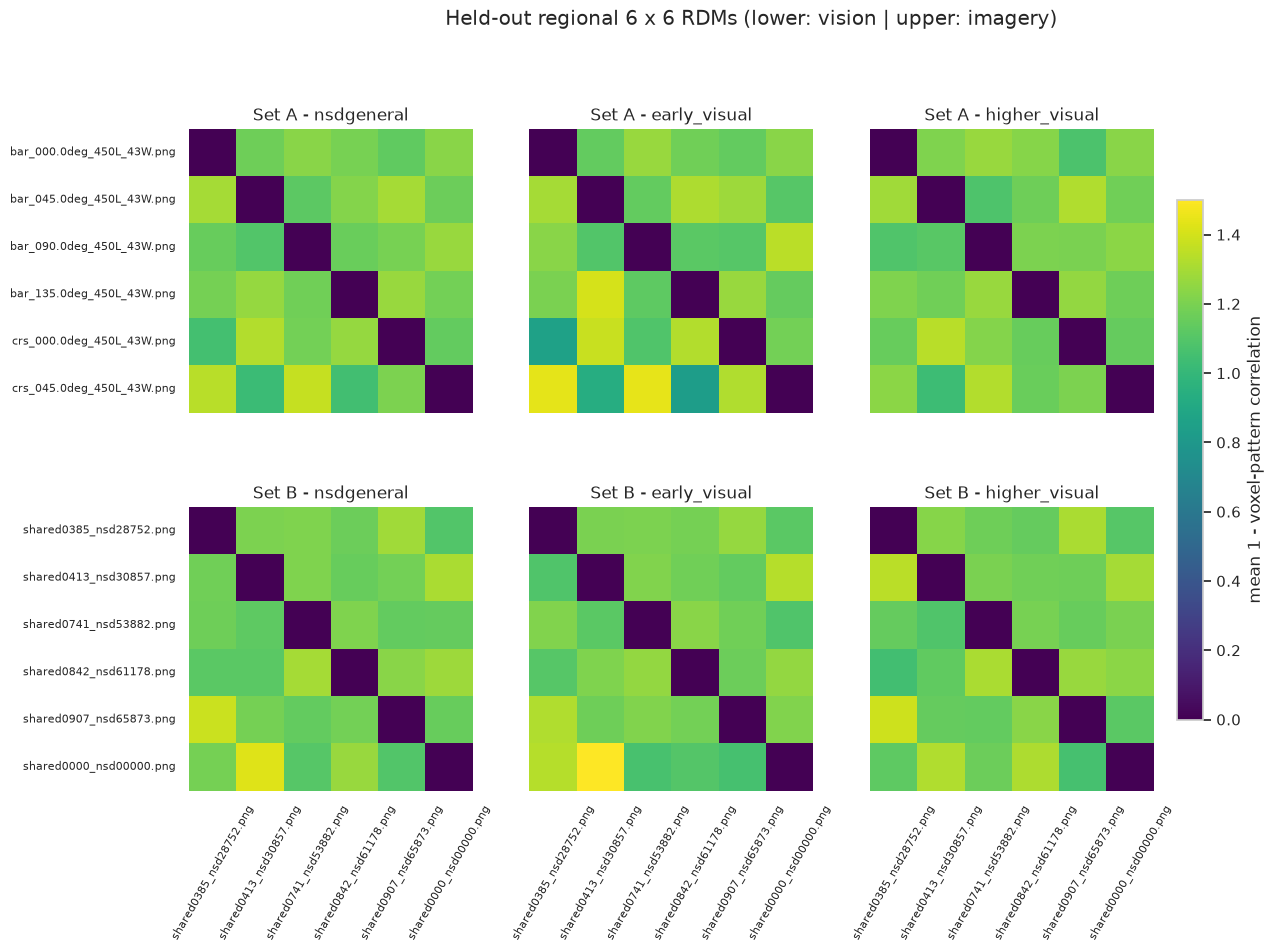

In [16]:
from matplotlib.colors import Normalize

HELDOUT_SUBJECTS = tuple(subject for subject in SUBJECTS if subject != PILOT_SUBJECT)
group_neural_rdms = {}
for roi_name in ROI_ORDER:
    for stimulus_set in STIMULUS_SETS:
        for task in ('vision', 'imagery'):
            group_neural_rdms[(roi_name, stimulus_set, task)] = np.mean(
                [
                    neural_rdms[(subject, roi_name, stimulus_set, task)]
                    for subject in HELDOUT_SUBJECTS
                ],
                axis=0,
            )

group_rdm_vmax = max(float(rdm.max()) for rdm in group_neural_rdms.values())
fig, axes = plt.subplots(len(STIMULUS_SETS), len(ROI_ORDER), figsize=(15, 9), squeeze=False)
for row, stimulus_set in enumerate(STIMULUS_SETS):
    labels = targets.loc[
        targets['stimulus_set'].eq(stimulus_set), 'target_name'
    ].tolist()
    for column, roi_name in enumerate(ROI_ORDER):
        vision_rdm = group_neural_rdms[(roi_name, stimulus_set, 'vision')]
        imagery_rdm = group_neural_rdms[(roi_name, stimulus_set, 'imagery')]
        split_rdm = np.zeros_like(vision_rdm)
        lower = np.tril_indices_from(split_rdm, k=-1)
        upper = np.triu_indices_from(split_rdm, k=1)
        split_rdm[lower] = vision_rdm[lower]
        split_rdm[upper] = imagery_rdm[upper]
        ax = axes[row, column]
        sns.heatmap(
            split_rdm, square=True, cmap='viridis', vmin=0, vmax=group_rdm_vmax,
            cbar=False, xticklabels=labels if row == len(STIMULUS_SETS) - 1 else False,
            yticklabels=labels if column == 0 else False, ax=ax,
        )
        ax.set_title(f'Set {stimulus_set} - {roi_name}')
        ax.tick_params(axis='x', rotation=60, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=Normalize(0, group_rdm_vmax), cmap='viridis'),
    ax=axes, shrink=.75, pad=.02,
)
colorbar.set_label('mean 1 - voxel-pattern correlation')
fig.suptitle(
    'Held-out regional 6 x 6 RDMs (lower: vision | upper: imagery)', y=.995
)
plt.show()

In [17]:
ROI_PAIR_CONTRASTS = {
    'nsdgeneral_minus_early': ('nsdgeneral', 'early_visual'),
    'nsdgeneral_minus_higher': ('nsdgeneral', 'higher_visual'),
    'early_minus_higher': ('early_visual', 'higher_visual'),
}

# Second-order RSA asks whether two cortical regions preserve the same ordering
# of the 15 target-pair dissimilarities, independent of their absolute scale.
roi_similarity_rows = []
for subject in SUBJECTS:
    for stimulus_set in STIMULUS_SETS:
        for task in ('vision', 'imagery'):
            for contrast_name, (left_roi, right_roi) in ROI_PAIR_CONTRASTS.items():
                roi_similarity_rows.append({
                    'subject': subject,
                    'phase': 'pilot' if subject == PILOT_SUBJECT else 'heldout',
                    'stimulus_set': stimulus_set,
                    'task': task,
                    'roi_pair': contrast_name.replace('_minus_', '_vs_'),
                    'rdm_rho': rdm_spearman(
                        neural_rdms[(subject, left_roi, stimulus_set, task)],
                        neural_rdms[(subject, right_roi, stimulus_set, task)],
                    ),
                })
roi_rdm_similarity = pd.DataFrame(roi_similarity_rows)

roi_similarity_group_rows = []
for keys, frame in roi_rdm_similarity.query("phase == 'heldout'").groupby(
    ['stimulus_set', 'task', 'roi_pair']
):
    values = frame['rdm_rho'].dropna().to_numpy()
    test = exact_sign_flip_test(values)
    roi_similarity_group_rows.append({
        **dict(zip(['stimulus_set', 'task', 'roi_pair'], keys)),
        'n_subjects': len(values),
        'mean_rho': values.mean(),
        'median_rho': np.median(values),
        'p_greater': test['p_greater'],
        'p_two_sided': test['p_two_sided'],
    })
roi_rdm_similarity_group = pd.DataFrame(roi_similarity_group_rows)

# Complete the neural transfer comparison for every set and ROI pair.
transfer_contrast_rows = []
for stimulus_set, frame in heldout_neural.groupby('stimulus_set'):
    wide = frame.pivot(index='subject', columns='roi', values='vision_imagery_rho')
    for contrast_name, (left_roi, right_roi) in ROI_PAIR_CONTRASTS.items():
        values = (wide[left_roi] - wide[right_roi]).dropna().to_numpy()
        test = exact_sign_flip_test(values)
        transfer_contrast_rows.append({
            'stimulus_set': stimulus_set,
            'contrast': contrast_name,
            'n_subjects': len(values),
            'mean_difference': values.mean(),
            'median_difference': np.median(values),
            'p_greater': test['p_greater'],
            'p_two_sided': test['p_two_sided'],
        })
regional_transfer_contrasts = pd.DataFrame(transfer_contrast_rows)

display(roi_rdm_similarity_group.sort_values(['stimulus_set', 'task', 'roi_pair']))
display(regional_transfer_contrasts.sort_values(['stimulus_set', 'contrast']))

,stimulus_set,task,roi_pair,n_subjects,mean_rho,median_rho,p_greater,p_two_sided
0,A,imagery,early_vs_higher,7,0.468367,0.453571,0.015625,0.031250
1,A,imagery,nsdgeneral_vs_early,7,0.728571,0.739286,0.007812,0.015625
2,A,imagery,nsdgeneral_vs_higher,7,0.722959,0.792857,0.007812,0.015625
3,A,vision,early_vs_higher,7,0.395918,0.385714,0.007812,0.015625
4,A,vision,nsdgeneral_vs_early,7,0.795408,0.792857,0.007812,0.015625
5,A,vision,nsdgeneral_vs_higher,7,0.693878,0.728571,0.007812,0.015625
6,B,imagery,early_vs_higher,7,0.362755,0.346429,0.007812,0.015625
7,B,imagery,nsdgeneral_vs_early,7,0.665816,0.657143,0.007812,0.015625
8,B,imagery,nsdgeneral_vs_higher,7,0.778061,0.796429,0.007812,0.015625
9,B,vision,early_vs_higher,7,0.446939,0.478571,0.007812,0.015625


,stimulus_set,contrast,n_subjects,mean_difference,median_difference,p_greater,p_two_sided
2,A,early_minus_higher,7,0.145918,0.171429,0.257812,0.515625
0,A,nsdgeneral_minus_early,7,-0.076020,-0.117857,0.726562,0.562500
1,A,nsdgeneral_minus_higher,7,0.069898,0.121429,0.296875,0.593750
5,B,early_minus_higher,7,-0.230612,-0.453571,0.843750,0.328125
3,B,nsdgeneral_minus_early,7,0.229592,0.232143,0.070312,0.140625
4,B,nsdgeneral_minus_higher,7,-0.001020,0.125000,0.515625,1.000000


,stimulus_set,task,feature_model,contrast,n_subjects,mean_difference,median_difference,p_greater,p_two_sided
2,A,imagery,CLIP,early_minus_higher,7,-0.034694,-0.075000,0.671875,0.687500
0,A,imagery,CLIP,nsdgeneral_minus_early,7,0.000510,-0.032143,0.500000,1.000000
1,A,imagery,CLIP,nsdgeneral_minus_higher,7,-0.034184,0.053571,0.687500,0.640625
5,A,imagery,HOG,early_minus_higher,7,0.077387,-0.032287,0.281250,0.562500
3,A,imagery,HOG,nsdgeneral_minus_early,7,-0.098912,-0.080718,0.953125,0.109375
4,A,imagery,HOG,nsdgeneral_minus_higher,7,-0.021525,-0.060987,0.601562,0.812500
8,A,vision,CLIP,early_minus_higher,7,0.025000,0.082143,0.312500,0.625000
6,A,vision,CLIP,nsdgeneral_minus_early,7,-0.041327,-0.050000,0.789062,0.437500
7,A,vision,CLIP,nsdgeneral_minus_higher,7,-0.016327,0.046429,0.671875,0.703125
11,A,vision,HOG,early_minus_higher,7,0.316979,0.466372,0.031250,0.062500


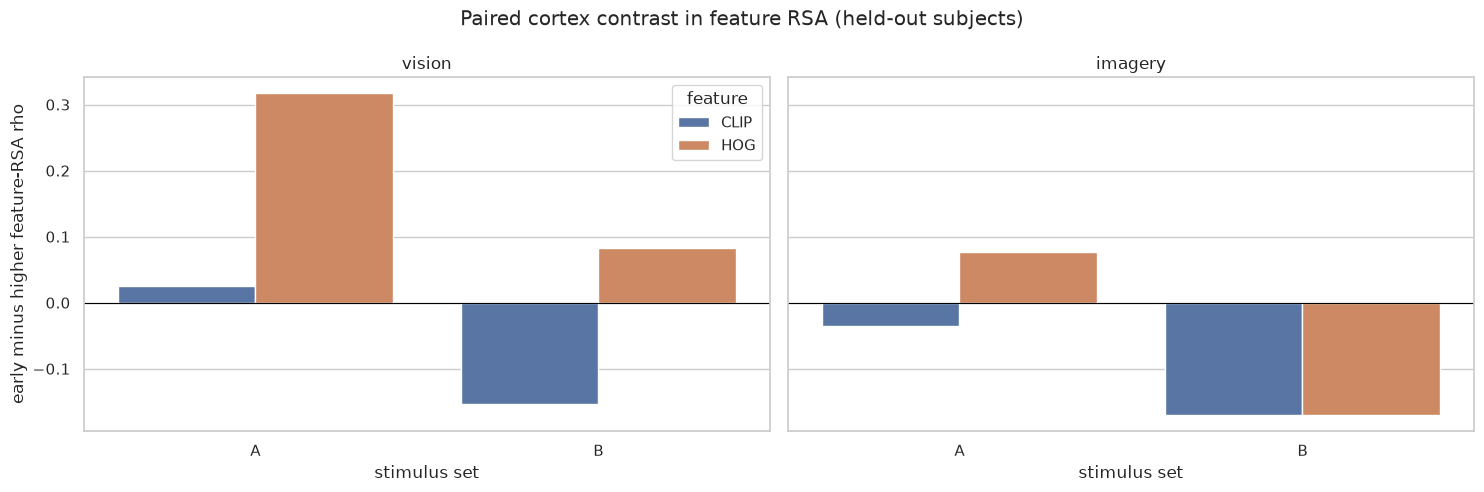

In [18]:
# Pairing within subject removes the between-subject offset before comparing ROIs.
feature_roi_rows = []
for keys, frame in heldout_rsa.groupby(['stimulus_set', 'task', 'feature_model']):
    stimulus_set, task, feature_model = keys
    wide = frame.pivot(index='subject', columns='roi', values='rsa_rho')
    for contrast_name, (left_roi, right_roi) in ROI_PAIR_CONTRASTS.items():
        values = (wide[left_roi] - wide[right_roi]).dropna().to_numpy()
        test = exact_sign_flip_test(values)
        feature_roi_rows.append({
            'stimulus_set': stimulus_set,
            'task': task,
            'feature_model': feature_model,
            'contrast': contrast_name,
            'n_subjects': len(values),
            'mean_difference': values.mean(),
            'median_difference': np.median(values),
            'p_greater': test['p_greater'],
            'p_two_sided': test['p_two_sided'],
        })
regional_feature_contrasts = pd.DataFrame(feature_roi_rows)
display(regional_feature_contrasts.sort_values(
    ['stimulus_set', 'task', 'feature_model', 'contrast']
))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, task in zip(axes, ('vision', 'imagery')):
    frame = regional_feature_contrasts[
        regional_feature_contrasts['task'].eq(task)
        & regional_feature_contrasts['contrast'].eq('early_minus_higher')
    ]
    sns.barplot(
        data=frame, x='stimulus_set', y='mean_difference', hue='feature_model', ax=ax,
    )
    ax.axhline(0, color='black', linewidth=.8)
    ax.set(
        title=task, xlabel='stimulus set',
        ylabel='early minus higher feature-RSA rho',
    )
right_legend = axes[1].get_legend()
if right_legend is not None:
    right_legend.remove()
axes[0].legend(title='feature')
fig.suptitle('Paired cortex contrast in feature RSA (held-out subjects)')
plt.tight_layout()

In [19]:
roi_rdm_similarity.to_csv(OUTPUT_DIR / 'regional_rdm_similarity_subject_level.csv', index=False)
roi_rdm_similarity_group.to_csv(OUTPUT_DIR / 'regional_rdm_similarity_group.csv', index=False)
regional_transfer_contrasts.to_csv(OUTPUT_DIR / 'regional_transfer_contrasts.csv', index=False)
regional_feature_contrasts.to_csv(OUTPUT_DIR / 'regional_feature_contrasts.csv', index=False)
np.savez_compressed(
    OUTPUT_DIR / 'regional_group_mean_6x6_rdms.npz',
    **{
        f'{roi_name}__set{stimulus_set}__{task}': rdm
        for (roi_name, stimulus_set, task), rdm in group_neural_rdms.items()
    },
)
print('Saved complete regional 6 x 6 analyses to:', OUTPUT_DIR)

Saved complete regional 6 x 6 analyses to: /home/jovyan/NHprojectNSDimagery/outputs/03_group_transfer_feature_rsa
